# Matplotlib 과제

In [1]:
# 한글이 포함된 그래프를 깨지지 않게 표시하기 위한 폰트 설정
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# font_candidates: 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

# available_fonts: 현재 환경에 설치된 폰트 이름 모음
available_fonts = {font.name for font in fm.fontManager.ttflist}

# platform.system(): 현재 운영체제 이름 확인
system_name = platform.system()
selected_font = None

# 폰트 후보 중 실제 설치된 첫 번째 한글 폰트 선택
for font_name in font_candidates.get(system_name, []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:

    # font.family: Matplotlib 기본 글꼴 설정
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Noto Sans KR 설치가 필요할 수 있습니다.")

# axes.unicode_minus=False: 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


설정된 한글 폰트: Malgun Gothic


## [실습 1] 다양한 그래프 활용 1

주어진 데이터에 대해 다음 그래프를 하나의 Figure에 배치.

1. 선 그래프
2. 막대 그래프
3. 히스토그램
4. 산점도

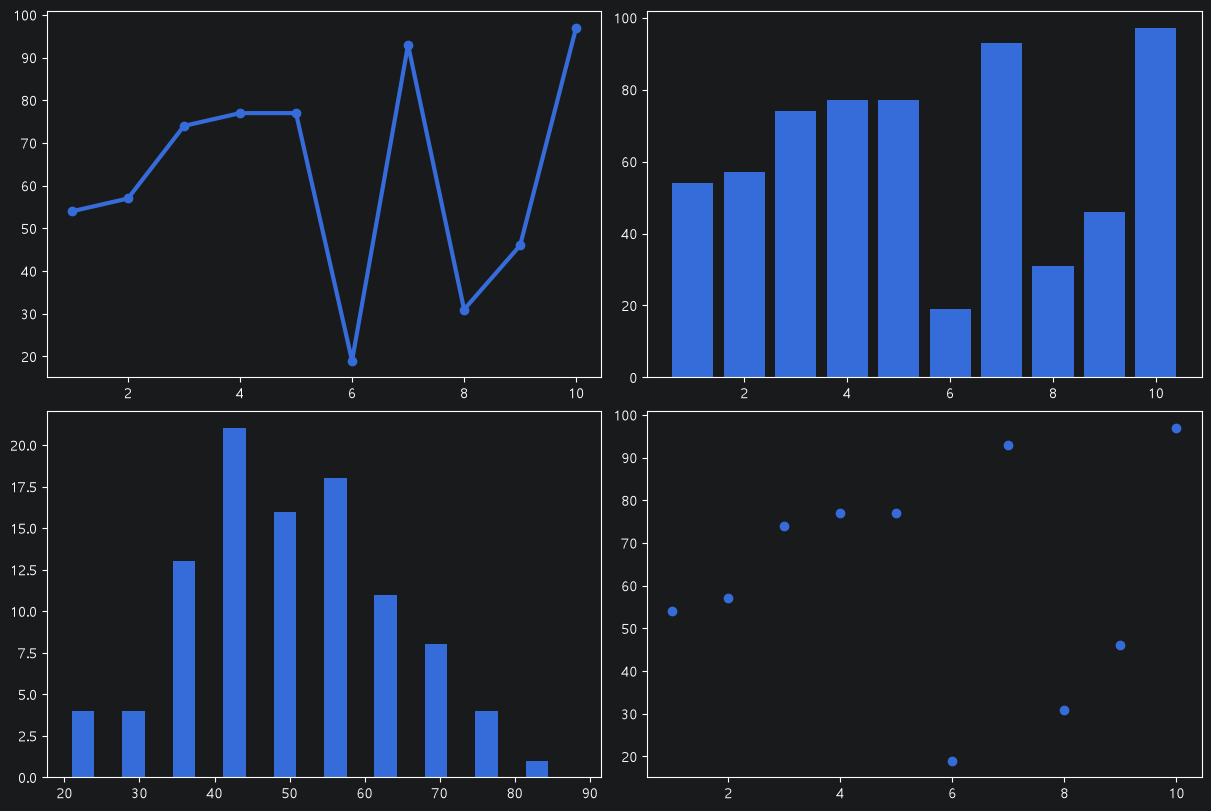

In [14]:
np.random.seed(0)
# x: 1부터 10까지의 정수 배열
# y: 10부터 99까지의 정수 중 10개를 무작위 생성
x = np.arange(1, 11)
y = np.random.randint(10, 100, 10)

# data: 평균 50, 표준편차 15인 정규분포 데이터 100개 생성
# 히스토그램으로 값의 분포를 확인하기 위한 데이터
data = np.random.normal(50, 15, 100)

# plt.subplots(): 여러 그래프를 배치할 Figure와 Axes 생성
# 2, 2: 2행 2열 배치
# figsize=(12, 8): 전체 Figure 크기
# constrained_layout=True: 그래프끼리 겹치지 않도록 간격 자동 조정
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# 1. 선 그래프: x 변화에 따른 y의 변화 흐름 확인
axes[0][0].plot(x, y, linewidth=3, marker='o')


# 2. 막대 그래프: x별 y 크기 비교
axes[0][1].bar(x, y, width=0.8)


# 3. 히스토그램: data가 어떤 구간에 많이 몰려 있는지 확인
axes[1][0].hist(data, width=3)


# 4. 산점도: x와 y의 관계를 점으로 확인
axes[1][1].scatter(x, y)


plt.show()

## [실습 2] 다양한 그래프 활용 2

월별 평균 기온, 월별 강수량, 학생들의 수학/영어 점수를 이용해 그래프를 작성.

In [17]:
# 실습 2 그래프 작성에 사용할 데이터 준비
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
avg_temperatures = [-1, 0, 5, 10, 15, 20, 25, 23, 19, 12, 5, 0]
rainfall = [50, 40, 60, 80, 100, 120, 150, 140, 110, 90, 70, 60]
math_scores = [85, 90, 88, 76, 95, 89, 72, 84, 91, 87]
english_scores = [78, 82, 85, 80, 88, 90, 84, 79, 85, 83]

# 긴 월 이름이 x축에서 겹칠 수 있으므로 약어를 별도로 생성
month_labels = [month[:3] for month in months]

### 1. 월별 평균 기온 선 그래프
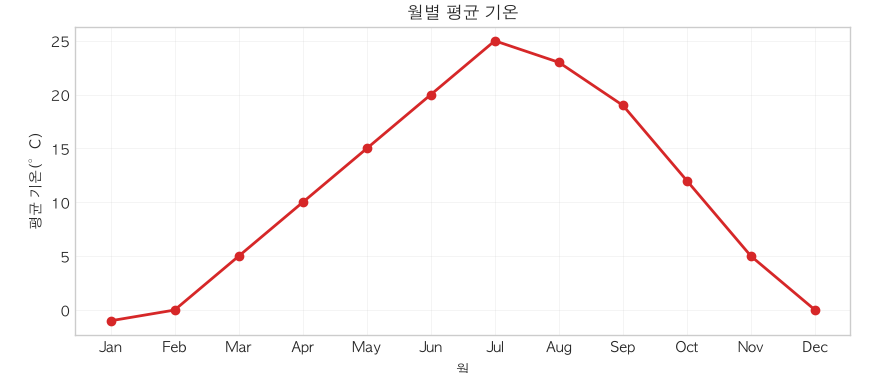

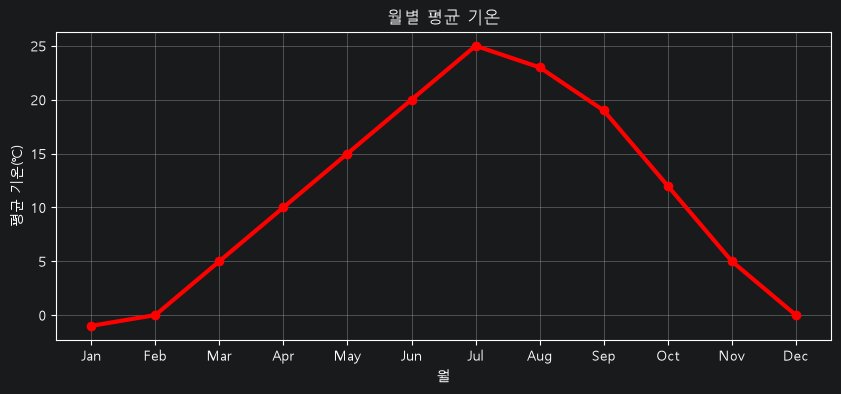

In [59]:
p_1 = plt.figure(figsize=(10, 4))

plt.plot(month_labels, avg_temperatures, color='red', linewidth=3, marker='o')
plt.title('월별 평균 기온')

plt.xlabel('월')
plt.ylabel('평균 기온(℃)')

plt.grid()
plt.show()

### 2. 월별 강수량 막대 그래프

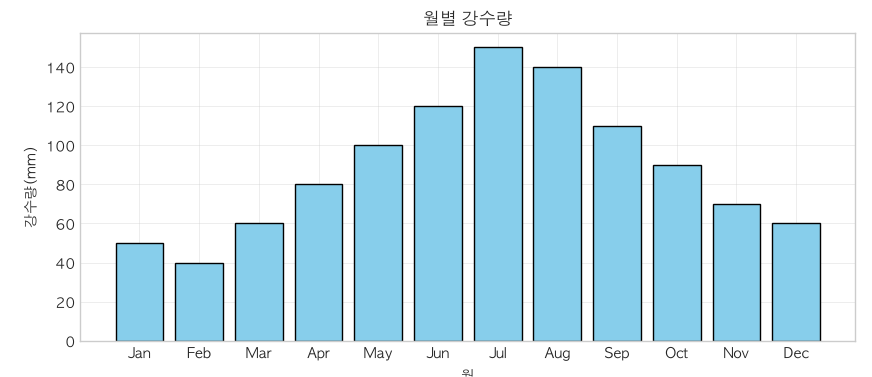

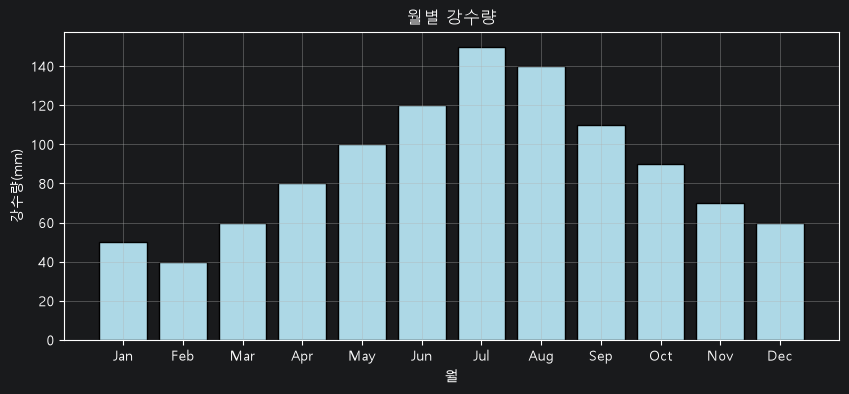

In [60]:
p_2 = plt.figure(figsize=(10, 4))

plt.bar(month_labels, rainfall, color='lightblue', width=0.8, edgecolor='black')

plt.title('월별 강수량')

plt.xlabel('월')
plt.ylabel('강수량(mm)')

plt.grid()
plt.show()

### 3. 수학과 영어 점수 박스플롯

- 두 과목 점수의 중앙값, 퍼짐 정도, 이상값 후보를 비교.
- 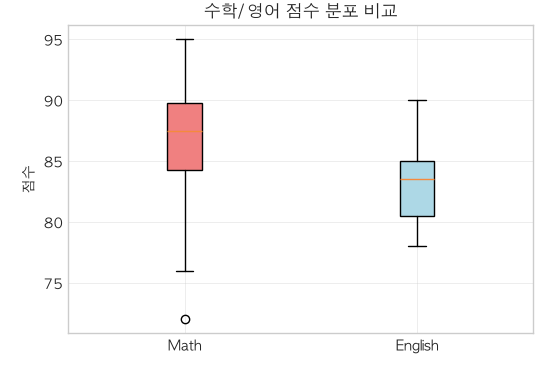

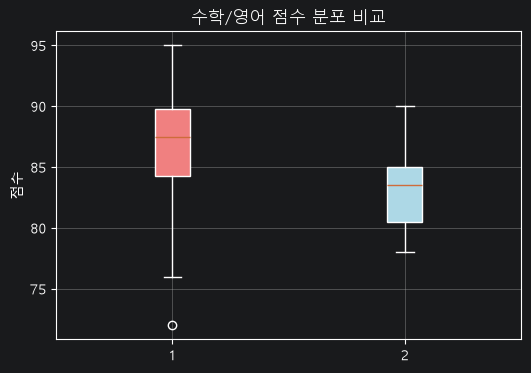

In [61]:
p_3 = plt.figure(figsize=(6, 4))

subjects = ['Math', 'English']
scores = [math_scores, english_scores]
colors = ['lightcoral', 'lightblue']

bplot = plt.boxplot(
    scores,
    label=subjects,
    # vert=True,
    patch_artist=True,
)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('수학/영어 점수 분포 비교')

plt.ylabel('점수')

plt.grid()
plt.show()

### 4. 수학 점수 히스토그램

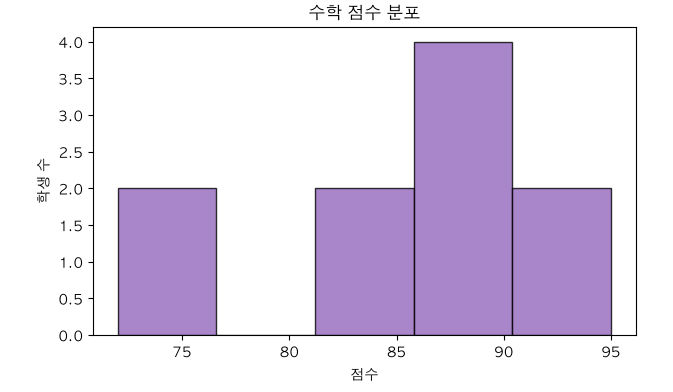

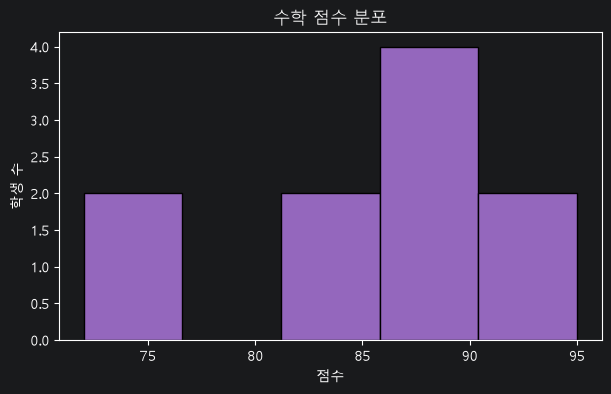

In [62]:
p_4 = plt.figure(figsize=(7, 4))

plt.hist(math_scores,
         bins=5,
         # color='orchid',
         color='tab:purple',
         edgecolor='black',)

plt.title('수학 점수 분포')

plt.xlabel('점수')
plt.ylabel('학생 수')

plt.show()

### 5. 수학 점수와 영어 점수 산점도

- 수학 점수가 높은 학생이 영어 점수도 높은 경향이 있는지 확인.
- 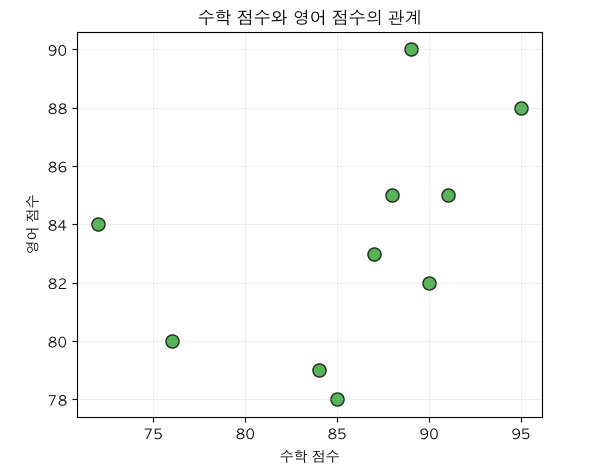

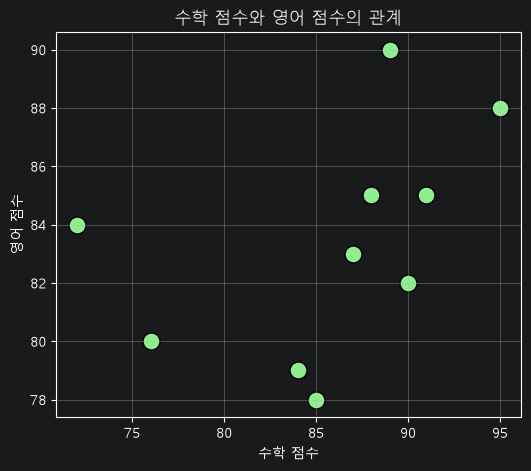

In [63]:
p_5 = plt.figure(figsize=(6, 5))

plt.scatter(math_scores,
            english_scores,
            marker='o',
            color='lightgreen',
            s=150,
            edgecolor='black',
)

plt.title('수학 점수와 영어 점수의 관계')

plt.xlabel('수학 점수')
plt.ylabel('영어 점수')

plt.grid()
plt.show()

### 6. 1~5의 모든 그래프를 하나의 Figure에 배치



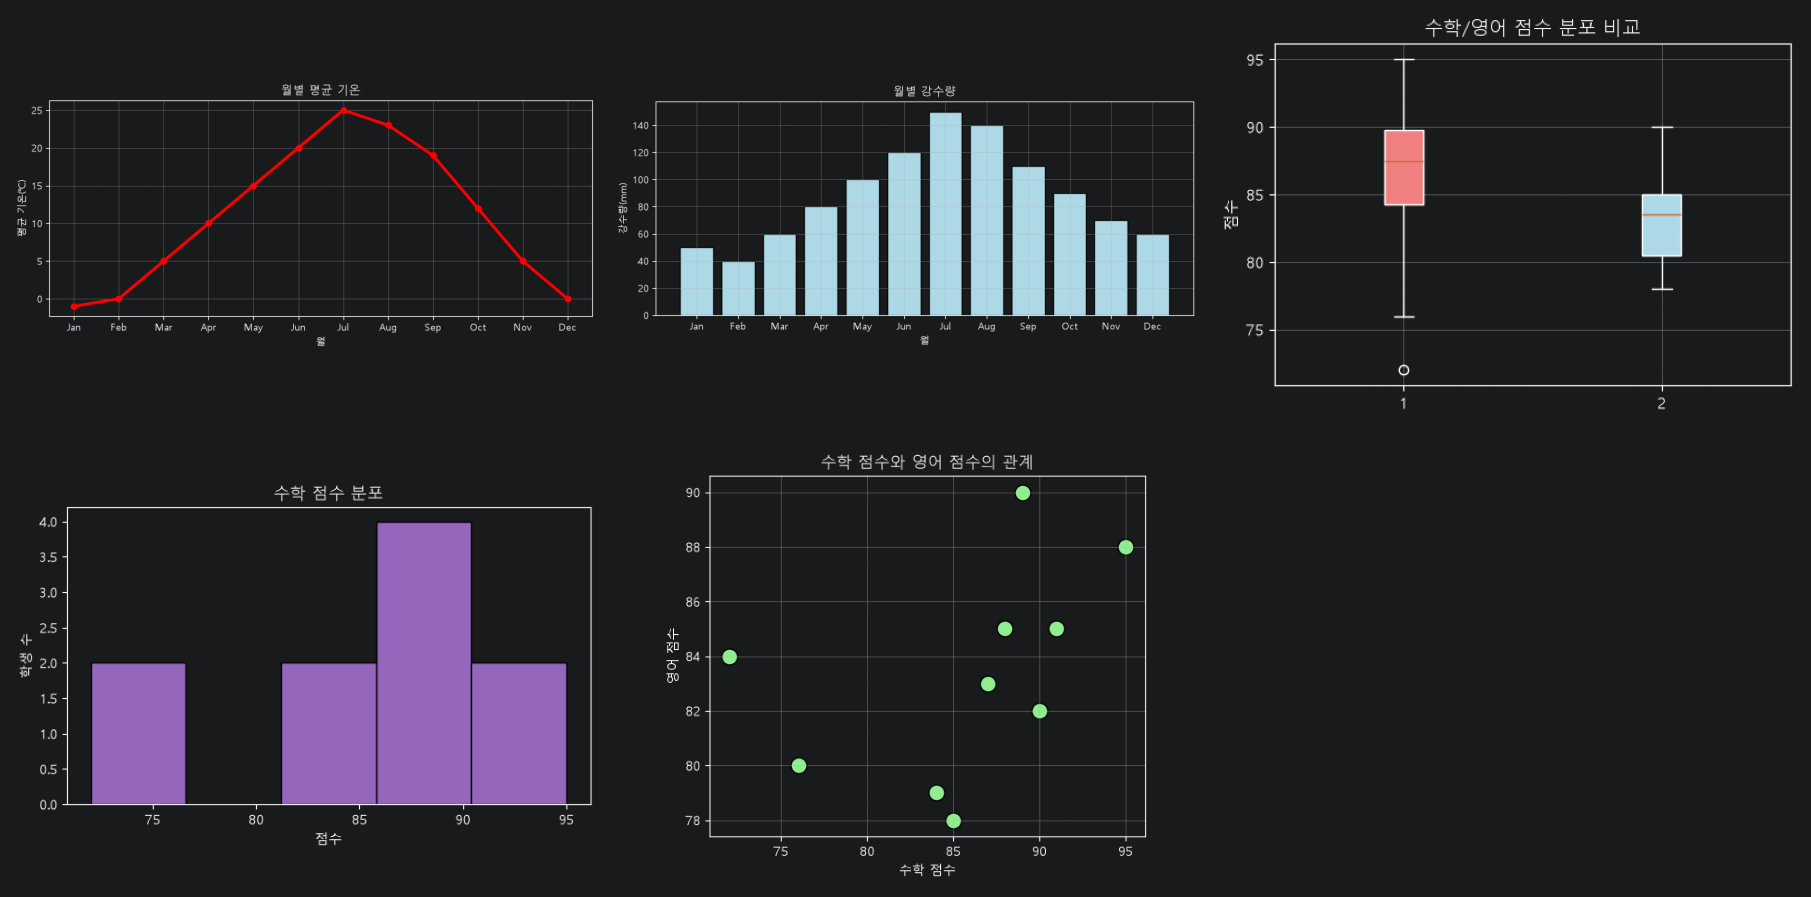

In [78]:
from io import BytesIO
import matplotlib.image as mpimg

# 목적: 실습 2의 5개 그래프를 하나의 Figure에 모아서 표시
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

# axes.ravel()
# - 2차원 형태의 axes 배열을 1차원으로 펼침
# - axes[0,0], axes[0,1]  -> axes[0], axes[1] 간단히 접근 가능
axes = axes.ravel()

plots = [p_1, p_2, p_3, p_4, p_5]

for idx, old_fig in enumerate(plots):
    buf = BytesIO()
    old_fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)

    img = mpimg.imread(buf)

    axes[idx].imshow(img)
    axes[idx].axis("off")

# 2행 3열 중 마지막 칸은 사용하지 않으므로 숨김
axes[5].axis("off")
plt.show()